# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [11]:
import numpy as np
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [12]:
import pandas as pd
import tensorflow as tf

# Inspect the shapes of the datasets
print(X_train.shape,y_train.shape,X_test.shape,y_test.shape)

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train_encoded=to_categorical(y_train.reshape(-1,1),num_classes=10)
y_test_encoded=to_categorical(y_test.reshape(-1,1),num_classes=10)


(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


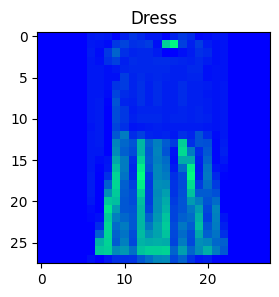

In [13]:
import matplotlib.pyplot as plt
# Verify the data looks as expected
select_index=251
plt.figure(figsize=(3, 3), dpi=100)
plt.imshow(X_train[select_index],cmap="winter",aspect="auto")
plt.title(class_names[y_train[select_index]])
plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here:**
The images are very low resolution and some of the images look like the label but not all of them.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [14]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()
model.add(tf.keras.Input(shape=(784,)))
# You can use `model.add(<layer>)` to add layers to the model
#model.add(tf.keras.layers.Dense(units=64,activation="relu"))
#model.add(tf.keras.layers.Dense(units=10,activation="softmax"))

#model.add(tf.keras.layers.Dense(units=64,))
model.add(tf.keras.layers.Dense(units=10))
#model.summary()

# Compile the model using `model.compile()`
model.compile(optimizer="SGD",loss="CategoricalCrossentropy",metrics=["accuracy"])
# Train the model with `model.fit()`
model.fit(X_train.reshape(X_train.shape[0],784),y_train_encoded,epochs=10,batch_size=100,verbose=2)
# Evaluate the model with `model.evaluate()`
model.evaluate(X_test.reshape(X_test.shape[0],784),y_test_encoded,batch_size=100)

Epoch 1/10
600/600 - 1s - 1ms/step - accuracy: 0.1774 - loss: 8.3926
Epoch 2/10
600/600 - 1s - 1ms/step - accuracy: 0.1879 - loss: 8.9002
Epoch 3/10
600/600 - 1s - 1ms/step - accuracy: 0.1831 - loss: 9.6013
Epoch 4/10
600/600 - 1s - 1ms/step - accuracy: 0.1856 - loss: 9.4958
Epoch 5/10
600/600 - 1s - 1ms/step - accuracy: 0.1113 - loss: 6.7731
Epoch 6/10
600/600 - 1s - 1ms/step - accuracy: 0.1000 - loss: 6.5070
Epoch 7/10
600/600 - 1s - 1ms/step - accuracy: 0.1000 - loss: 6.6743
Epoch 8/10
600/600 - 1s - 1ms/step - accuracy: 0.1000 - loss: 6.7793
Epoch 9/10
600/600 - 1s - 1ms/step - accuracy: 0.1000 - loss: 6.8156
Epoch 10/10
600/600 - 1s - 1ms/step - accuracy: 0.1000 - loss: 6.8462
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1000 - loss: 6.9099


[6.9098591804504395, 0.10000000149011612]

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here:** The baseline model has  very low accrucay. Without an activation function the model is not able to capture the differences between images as all features are not linear. As you can see in the commented out code I have tried using activation function and the accrucary was around 80 % with two layers. This model is too simple to simple to capture the difference between features in this dataset. 

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [15]:
from keras.layers import Conv2D


# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model_cnn = Sequential()
model_cnn.add(Conv2D(filters=16,kernel_size=(3,3),activation="relu",input_shape=(28,28,1)))
model_cnn.add(Flatten())
model_cnn.add(tf.keras.layers.Dense(units=64,activation="relu"))
model_cnn.add(tf.keras.layers.Dense(units=10,activation="softmax"))
#model_cnn.summary()
model_cnn.compile(optimizer="SGD",loss="CategoricalCrossentropy",metrics=["accuracy"])
# Train the model
model_cnn.fit(X_train,y_train_encoded,epochs=10,batch_size=100,verbose=2)
# Evaluate the model
model_simple_accuracy=model_cnn.evaluate(X_test,y_test_encoded,batch_size=100)

model_simple_accuracy

Epoch 1/10
600/600 - 5s - 9ms/step - accuracy: 0.7228 - loss: 0.8299
Epoch 2/10
600/600 - 5s - 8ms/step - accuracy: 0.8102 - loss: 0.5350
Epoch 3/10
600/600 - 5s - 8ms/step - accuracy: 0.8286 - loss: 0.4852
Epoch 4/10
600/600 - 5s - 8ms/step - accuracy: 0.8425 - loss: 0.4519
Epoch 5/10
600/600 - 4s - 7ms/step - accuracy: 0.8465 - loss: 0.4364
Epoch 6/10
600/600 - 4s - 7ms/step - accuracy: 0.8554 - loss: 0.4145
Epoch 7/10
600/600 - 4s - 7ms/step - accuracy: 0.8575 - loss: 0.4049
Epoch 8/10
600/600 - 4s - 7ms/step - accuracy: 0.8625 - loss: 0.3905
Epoch 9/10
600/600 - 4s - 7ms/step - accuracy: 0.8662 - loss: 0.3809
Epoch 10/10
600/600 - 4s - 7ms/step - accuracy: 0.8688 - loss: 0.3702
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8591 - loss: 0.3948


[0.3948274254798889, 0.8590999841690063]

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here:** The accuracy has significantly imporved. This improvement can be attributed to the convulation layer before the ann and the ann layers using activation functions to model the complex behaviour.  

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [16]:
# A. Test Hyperparameters
model_name=[]
model_accuracy=[]
model_val_accuracy=[]

for num_filters in [8,16,24,32]:
    num_neurons=round((num_filters/16)*64)
    
    model_cnn = Sequential()
    model_cnn.add(Conv2D(filters=num_filters,kernel_size=(3,3),activation="relu",input_shape=(28,28,1)))
    model_cnn.add(Flatten())
    model_cnn.add(tf.keras.layers.Dense(units=num_neurons,activation="relu"))
    model_cnn.add(tf.keras.layers.Dense(units=10,activation="softmax"))
    #model_cnn.summary()
    model_cnn.compile(optimizer="SGD",loss="CategoricalCrossentropy",metrics=["accuracy"])
    # Train the model
    history=model_cnn.fit(X_train,y_train_encoded,epochs=10,batch_size=100,verbose=2,validation_split= 0.2)
    # Evaluate the model
    name=f"model_filter{num_filters}_layer{num_neurons}"
    model_name.append(name)
    model_accuracy.append(history.history["accuracy"])
    model_val_accuracy.append(history.history["val_accuracy"])
    
        



Epoch 1/10
480/480 - 3s - 6ms/step - accuracy: 0.7102 - loss: 0.8835 - val_accuracy: 0.7772 - val_loss: 0.6055
Epoch 2/10
480/480 - 4s - 9ms/step - accuracy: 0.7990 - loss: 0.5661 - val_accuracy: 0.7987 - val_loss: 0.5792
Epoch 3/10
480/480 - 2s - 5ms/step - accuracy: 0.8181 - loss: 0.5096 - val_accuracy: 0.8142 - val_loss: 0.5241
Epoch 4/10
480/480 - 2s - 5ms/step - accuracy: 0.8310 - loss: 0.4806 - val_accuracy: 0.8377 - val_loss: 0.4609
Epoch 5/10
480/480 - 3s - 5ms/step - accuracy: 0.8393 - loss: 0.4575 - val_accuracy: 0.8443 - val_loss: 0.4523
Epoch 6/10
480/480 - 3s - 6ms/step - accuracy: 0.8460 - loss: 0.4384 - val_accuracy: 0.8415 - val_loss: 0.4576
Epoch 7/10
480/480 - 2s - 5ms/step - accuracy: 0.8497 - loss: 0.4277 - val_accuracy: 0.8503 - val_loss: 0.4336
Epoch 8/10
480/480 - 2s - 5ms/step - accuracy: 0.8541 - loss: 0.4134 - val_accuracy: 0.8568 - val_loss: 0.4110
Epoch 9/10
480/480 - 2s - 5ms/step - accuracy: 0.8556 - loss: 0.4041 - val_accuracy: 0.8394 - val_loss: 0.4420
E

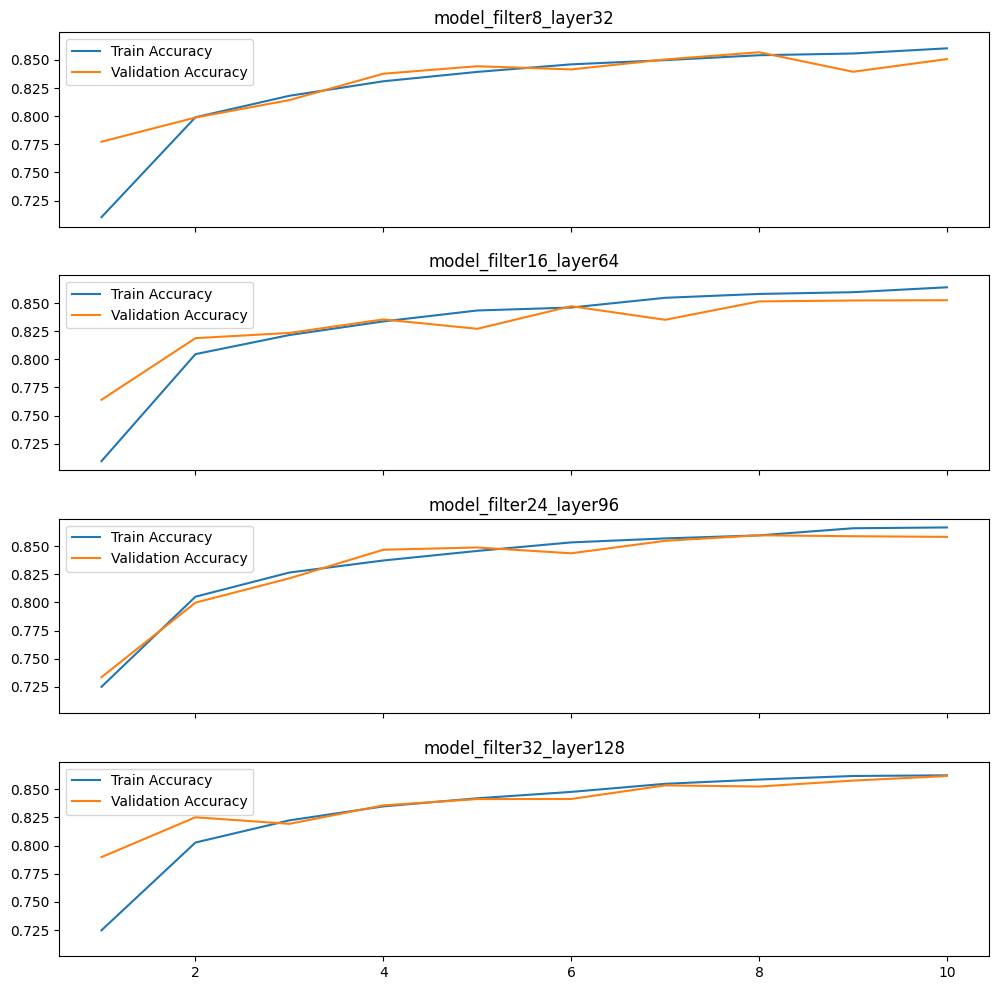

In [25]:
from matplotlib import pyplot as plt


fig,axes=plt.subplots(4,1,figsize=(12, 12),sharex=True,sharey=True)
plt.subplots_adjust(wspace=0.5, hspace=0.25)

for i,ax in enumerate(axes):
    ax.plot([1,2,3,4,5,6,7,8,9,10],model_accuracy[i],label="Train Accuracy")
    ax.plot([1,2,3,4,5,6,7,8,9,10],model_val_accuracy[i],label="Validation Accuracy")
    ax.legend()
    ax.set_title(model_name[i])
plt.show()



Epoch 1/10
480/480 - 3s - 6ms/step - accuracy: 0.4933 - loss: 1.4411 - val_accuracy: 0.7754 - val_loss: 0.7049
Epoch 2/10
480/480 - 2s - 4ms/step - accuracy: 0.6697 - loss: 0.9208 - val_accuracy: 0.7939 - val_loss: 0.5870
Epoch 3/10
480/480 - 2s - 4ms/step - accuracy: 0.7038 - loss: 0.8129 - val_accuracy: 0.8099 - val_loss: 0.5354
Epoch 4/10
480/480 - 2s - 4ms/step - accuracy: 0.7184 - loss: 0.7662 - val_accuracy: 0.8166 - val_loss: 0.5212
Epoch 5/10
480/480 - 7s - 15ms/step - accuracy: 0.7276 - loss: 0.7411 - val_accuracy: 0.8168 - val_loss: 0.5019
Epoch 6/10
480/480 - 6s - 12ms/step - accuracy: 0.7348 - loss: 0.7260 - val_accuracy: 0.8218 - val_loss: 0.4924
Epoch 7/10
480/480 - 4s - 7ms/step - accuracy: 0.7402 - loss: 0.7055 - val_accuracy: 0.8274 - val_loss: 0.4818
Epoch 8/10
480/480 - 2s - 4ms/step - accuracy: 0.7446 - loss: 0.6919 - val_accuracy: 0.8223 - val_loss: 0.4936
Epoch 9/10
480/480 - 2s - 4ms/step - accuracy: 0.7469 - loss: 0.6802 - val_accuracy: 0.8338 - val_loss: 0.4699

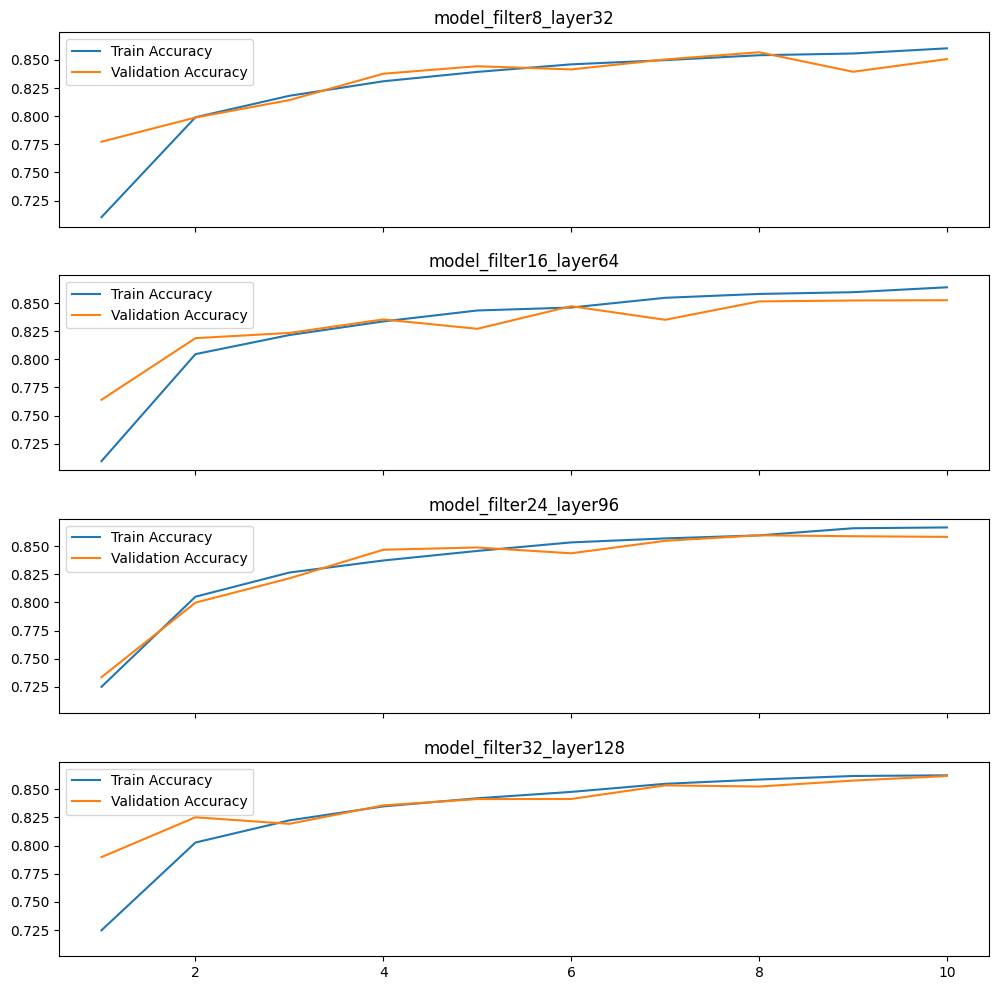

In [27]:
# B. Test presence or absence of regularization
from tensorflow.keras.layers import Dropout

model_name_dropput=[]
model_accuracy_dropout=[]
model_val_accuracy_dropout=[]

for num_filters in [8,16,24,32]:
    num_neurons=round((num_filters/16)*64)
    
    model_cnn = Sequential()
    model_cnn.add(Conv2D(filters=num_filters,kernel_size=(3,3),activation="relu",input_shape=(28,28,1)))
    model_cnn.add(Flatten())
    model_cnn.add(tf.keras.layers.Dense(units=num_neurons,activation="relu"))
    model_cnn.add(Dropout(0.5))
    model_cnn.add(tf.keras.layers.Dense(units=10,activation="softmax"))
    #model_cnn.summary()
    model_cnn.compile(optimizer="SGD",loss="CategoricalCrossentropy",metrics=["accuracy"])
    # Train the model
    history=model_cnn.fit(X_train,y_train_encoded,epochs=10,batch_size=100,verbose=2,validation_split= 0.2)
    # Evaluate the model
    name=f"model_filter{num_filters}_layer{num_neurons}"
    model_name_dropput.append(name)
    model_accuracy_dropout.append(history.history["accuracy"])
    model_val_accuracy_dropout.append(history.history["val_accuracy"])



fig,axes=plt.subplots(4,1,figsize=(12, 12),sharex=True,sharey=True)
plt.subplots_adjust(wspace=0.5, hspace=0.25)

for i,ax in enumerate(axes):
    ax.plot([1,2,3,4,5,6,7,8,9,10],model_accuracy[i],label="Train Accuracy")
    ax.plot([1,2,3,4,5,6,7,8,9,10],model_val_accuracy[i],label="Validation Accuracy")
    ax.legend()
    ax.set_title(model_name[i])
plt.show()


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here:** Going over the results of all of them the best model is with 32 filters and 128 dense layer. The Dropout of 0.5 has not significanlty added to accuracy but having a droput regulaization would help in generalizing when using a large number of filters and fully connected layers.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [28]:
model_cnn_final = Sequential()
model_cnn_final.add(Conv2D(filters=32,kernel_size=(3,3),activation="relu",input_shape=(28,28,1)))
model_cnn_final.add(Flatten())
model_cnn_final.add(tf.keras.layers.Dense(units=128,activation="relu"))
model_cnn_final.add(Dropout(0.5))
model_cnn_final.add(tf.keras.layers.Dense(units=10,activation="softmax"))
#model_cnn.summary()
model_cnn_final.compile(optimizer="SGD",loss="CategoricalCrossentropy",metrics=["accuracy"])
# Train the model
model_cnn_final.fit(X_train,y_train_encoded,epochs=10,batch_size=100,verbose=2,validation_split= 0.2)
# Evaluate the model
model_cnn_final.evaluate(X_test,y_test_encoded,batch_size=100)

Epoch 1/10


c:\Users\kirti\.conda\envs\dsi_participant\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


480/480 - 7s - 15ms/step - accuracy: 0.6628 - loss: 1.0192 - val_accuracy: 0.7965 - val_loss: 0.5804
Epoch 2/10
480/480 - 7s - 14ms/step - accuracy: 0.7818 - loss: 0.6293 - val_accuracy: 0.8161 - val_loss: 0.5072
Epoch 3/10
480/480 - 9s - 18ms/step - accuracy: 0.7989 - loss: 0.5661 - val_accuracy: 0.8298 - val_loss: 0.4674
Epoch 4/10
480/480 - 11s - 24ms/step - accuracy: 0.8129 - loss: 0.5299 - val_accuracy: 0.8365 - val_loss: 0.4461
Epoch 5/10
480/480 - 10s - 22ms/step - accuracy: 0.8196 - loss: 0.5063 - val_accuracy: 0.8416 - val_loss: 0.4324
Epoch 6/10
480/480 - 13s - 28ms/step - accuracy: 0.8275 - loss: 0.4853 - val_accuracy: 0.8455 - val_loss: 0.4238
Epoch 7/10
480/480 - 43s - 90ms/step - accuracy: 0.8298 - loss: 0.4734 - val_accuracy: 0.8420 - val_loss: 0.4190
Epoch 8/10
480/480 - 24s - 50ms/step - accuracy: 0.8353 - loss: 0.4626 - val_accuracy: 0.8508 - val_loss: 0.4096
Epoch 9/10
480/480 - 22s - 46ms/step - accuracy: 0.8387 - loss: 0.4527 - val_accuracy: 0.8547 - val_loss: 0.40

[0.41132020950317383, 0.8513000011444092]

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here:** The final model is nearly 8.5 times better than baseline model.The cnn has better performance as it has convulation layer which finds the right features and dense layer with activation finds the correct patterns within the data for classification. If given more time would have experimented with more layers of covulation with max pooling layer and more layers of neurons.  

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.